# H2-1 확장 — 5단계: 평행추세 사전검정 (17~32주)

**목적**: 캠페인이 시작되기 전(17~32주) 구간에서, "향후 캠페인을 받을 가구군"과
"끝까지 안 받을 가구군"의 지출 추세가 이미 달랐는지 확인. 다르다면 6단계(본 회귀)에서
나오는 차이가 캠페인 효과인지 원래 다른 궤적이었는지 구분이 흐려짐.

**검정 방법**: `per_hh_spend ~ WEEK_NO * will_receive` 회귀, `WEEK_NO:will_receive`
상호작용항이 유의하지 않아야 평행추세 가정에 부합.


In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Noto Sans CJK JP", "Noto Sans CJK KR"]
available = {f.name for f in fm.fontManager.ttflist}
font_name = next((c for c in candidates if c in available), None)
if font_name:
    plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

pd.set_option('display.max_columns', 100)

DATA_DIR = "data/"
TIER_MIN_WEEK, TIER_MAX_WEEK = 17, 32


## (재구성) 계층 고정 + 수신예정 라벨

In [2]:
tx = pd.read_csv(DATA_DIR + "transaction_data.csv", usecols=["household_key", "DAY", "WEEK_NO", "SALES_VALUE"])
campaign_table = pd.read_csv(DATA_DIR + "campaign_table.csv")

all_households = tx["household_key"].unique()
tier_window = tx[(tx["WEEK_NO"] >= TIER_MIN_WEEK) & (tx["WEEK_NO"] <= TIER_MAX_WEEK)]
n_weeks_tier = TIER_MAX_WEEK - TIER_MIN_WEEK + 1
avg_weekly_spend = (tier_window.groupby("household_key")["SALES_VALUE"].sum() / n_weeks_tier).reindex(all_households).fillna(0)
tier3 = pd.qcut(avg_weekly_spend, 3, labels=["저지출", "중지출", "고지출"])
tier_df = pd.DataFrame({"avg_weekly_spend_pre": avg_weekly_spend, "tier3": tier3})

recipients = set(campaign_table["household_key"].unique())
never_recipients = set(all_households) - recipients
tier_df["will_receive"] = tier_df.index.to_series().isin(recipients).astype(int)

print(f"향후 캠페인 수신 가구: {len(recipients):,} / 미수신 가구: {len(never_recipients):,}")


향후 캠페인 수신 가구: 1,584 / 미수신 가구: 916


### ⚠️ 그룹별 가구 수(분모) 계산 시 주의

`groupby(...).nunique()`로 "거래가 실제로 있었던 가구"만 세면, 17~32주 거래가 0인
142개 가구가 통째로 분모에서 빠지는 버그가 생긴다(1단계에서 확인한 바닥효과 가구).
아래는 **전체 2,500가구를 will_receive 기준으로 나눈 진짜 가구 수**를 사용한다.

In [3]:
group_sizes_overall = tier_df.groupby("will_receive").size()
print("[전체 표본] will_receive 별 가구 수:")
print(group_sizes_overall)

print()
group_sizes_by_tier = tier_df.groupby(["tier3", "will_receive"], observed=True).size().unstack()
print("[계층별] will_receive 별 가구 수:")
print(group_sizes_by_tier)


[전체 표본] will_receive 별 가구 수:
will_receive
0     916
1    1584
dtype: int64

[계층별] will_receive 별 가구 수:
will_receive    0    1
tier3                 
저지출           624  210
중지출           243  591
고지출            49  783


## 5-1. 전체 표본 — 수신예정 vs 미수신 사전추세 비교

In [4]:
pre = tier_window.copy()
pre["will_receive"] = pre["household_key"].isin(recipients).astype(int)

weekly = pre.groupby(["WEEK_NO", "will_receive"])["SALES_VALUE"].sum().reset_index()
full_idx = pd.MultiIndex.from_product(
    [range(TIER_MIN_WEEK, TIER_MAX_WEEK + 1), [0, 1]], names=["WEEK_NO", "will_receive"]
)
weekly = weekly.set_index(["WEEK_NO", "will_receive"]).reindex(full_idx, fill_value=0).reset_index()
weekly["per_hh"] = weekly.apply(lambda r: r["SALES_VALUE"] / group_sizes_overall[r["will_receive"]], axis=1)

reg_overall = smf.ols("per_hh ~ WEEK_NO * will_receive", data=weekly).fit()
print(reg_overall.summary().tables[1])

interaction_p = reg_overall.pvalues["WEEK_NO:will_receive"]
interaction_coef = reg_overall.params["WEEK_NO:will_receive"]
print(f"\nWEEK_NO:will_receive 상호작용 계수 = {interaction_coef:.4f}, p = {interaction_p:.4f}")
if interaction_p < 0.05:
    print("=> 사전추세가 이미 유의하게 다름 (경고)")
elif interaction_p < 0.10:
    print("=> 5% 기준 유의하지 않으나 10% 수준 경계선 -- 참고 필요")
else:
    print("=> 사전추세 차이가 유의하지 않음 (평행추세 가정에 부합)")


                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               13.7600      2.942      4.677      0.000       7.734      19.786
WEEK_NO                 -0.1467      0.118     -1.243      0.224      -0.388       0.095
will_receive            27.6555      4.160      6.647      0.000      19.134      36.177
WEEK_NO:will_receive     0.2962      0.167      1.775      0.087      -0.046       0.638

WEEK_NO:will_receive 상호작용 계수 = 0.2962, p = 0.0868
=> 5% 기준 유의하지 않으나 10% 수준 경계선 -- 참고 필요


### 시각적 확인 — 주차별 가구당 평균 지출 추세

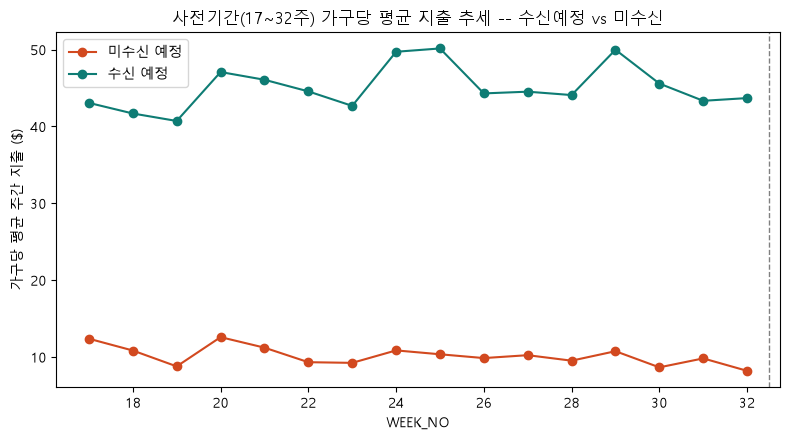

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for wr, label, color in [(0, "미수신 예정", "#D2491F"), (1, "수신 예정", "#0E7C74")]:
    sub = weekly[weekly["will_receive"] == wr].sort_values("WEEK_NO")
    ax.plot(sub["WEEK_NO"], sub["per_hh"], marker="o", label=label, color=color)

ax.axvline(x=32.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("WEEK_NO")
ax.set_ylabel("가구당 평균 주간 지출 ($)")
ax.set_title("사전기간(17~32주) 가구당 평균 지출 추세 -- 수신예정 vs 미수신")
ax.legend()
plt.tight_layout()
plt.show()


**해석**: 두 그룹의 지출 **수준(레벨)** 차이는 원래 존재하는 게 당연하다(캠페인이 원래
고지출 고객에게 더 많이 갔으니까). 평행추세 검정에서 보는 건 수준 차이가 아니라 **기울기(추세)**가
같은지다. 위 그래프에서 두 선이 평행하게 움직이는지, 아니면 한쪽이 점점 벌어지는지를 육안으로도
같이 확인한다.

## 5-2. 계층(tier3)별 — 같은 계층 안에서 비교

계층 구성 차이(수신예정 가구가 고지출 계층에 훨씬 많음)를 통제한, 더 정밀한 버전.

In [6]:
pre_tier = pre.merge(tier_df[["tier3"]], left_on="household_key", right_index=True, how="left")

results = []
for t in ["저지출", "중지출", "고지출"]:
    sub = pre_tier[pre_tier["tier3"] == t]
    sizes_t = group_sizes_by_tier.loc[t]

    weekly_t = sub.groupby(["WEEK_NO", "will_receive"])["SALES_VALUE"].sum().reset_index()
    full_idx_t = pd.MultiIndex.from_product(
        [range(TIER_MIN_WEEK, TIER_MAX_WEEK + 1), [0, 1]], names=["WEEK_NO", "will_receive"]
    )
    weekly_t = weekly_t.set_index(["WEEK_NO", "will_receive"]).reindex(full_idx_t, fill_value=0).reset_index()
    weekly_t["per_hh"] = weekly_t.apply(lambda r: r["SALES_VALUE"] / sizes_t[r["will_receive"]], axis=1)

    reg_t = smf.ols("per_hh ~ WEEK_NO * will_receive", data=weekly_t).fit()
    coef = reg_t.params.get("WEEK_NO:will_receive", np.nan)
    p = reg_t.pvalues.get("WEEK_NO:will_receive", np.nan)
    results.append({
        "계층": t,
        "미수신가구": int(sizes_t[0]), "수신예정가구": int(sizes_t[1]),
        "상호작용계수": round(coef, 4), "p값": round(p, 4),
        "판정": "차이 유의(경고)" if p < 0.05 else ("경계선(10%)" if p < 0.10 else "평행추세 부합")
    })

result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))


 계층  미수신가구  수신예정가구  상호작용계수     p값       판정
저지출    624     210  0.0254 0.7641  평행추세 부합
중지출    243     591  0.3083 0.0534 경계선(10%)
고지출     49     783  0.3333 0.6130  평행추세 부합


## 결과 해석

| 검정 | 상호작용 p값 | 판정 |
|---|---|---|
| 전체 표본 | 0.087 | 5% 기준 통과, 10% 기준 경계선 |
| 저지출 계층 내부 | 0.764 | 평행추세 부합 (안전) |
| 중지출 계층 내부 | 0.053 | **경계선 — 5% 기준 바로 턱밑** |
| 고지출 계층 내부 | 0.613 | 평행추세 부합 (단, 미수신 49명뿐이라 검정력 약함) |

**종합 판단**

1. **완전히 깨끗한 통과는 아닙니다.** 전체 표본과 중지출 계층 내부 검정 모두 p=0.05~0.09 사이의
   경계선에 있습니다. 5% 기준으로는 "유의하지 않다"고 말할 수 있지만, 여유 있게 통과한 건 아닙니다.
2. **고지출 계층은 검정 자체의 힘이 약합니다.** 미수신 가구가 49명뿐이라, 실제로 추세 차이가 있어도
   이 표본 크기로는 못 잡아낼 가능성이 있습니다. "차이가 없다"를 강하게 주장하기 어렵습니다.
3. **저지출 계층만 깔끔하게 통과했습니다** (p=0.764, 미수신 624명으로 표본도 충분).

**6단계로 넘어갈 때 반영할 것**

- 평행추세가 "완전히 확인됨"이 아니라 **"저지출 계층은 안전, 중지출·전체는 경계선, 고지출은 검정력 부족으로 불확실"**이라고
  정확하게 서술해야 합니다.
- 6단계 회귀 결과를 해석할 때, 특히 **중지출·고지출 계층에서 나오는 효과는 "캠페인 때문"과
  "원래 다른 추세였을 가능성"을 완전히 분리하지 못한 채로 나온 결과**라는 단서를 달아야 합니다.
- 저지출 계층에서 나오는 결과가 상대적으로 가장 깨끗한 인과적 해석이 가능합니다.

## 다음 단계
6단계(본 회귀: 가구·주차 고정효과 + Type×계층 + 클러스터 SE)로 진행 가능하나,
위 3가지 단서를 최종 결론에 반드시 포함할 것.